<a href="https://colab.research.google.com/github/escobarloorfrancisco2001-lang/Operaciones-2/blob/main/PROYECTO_OPERACIONES_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== OPTIMIZADOR DE TANQUE: REPORTE + GRÁFICO ===
Por favor, ingrese los parámetros:
  > Volumen deseado (V0): 10
  > Costo Base (C0): 120
  > Factor C1: 150
  > Constante k: 0.04

>> INICIO: Radio r=0.5 | Costo=$6170.78
---------------------------------------------------------------------------
Iter  | Acción             | Radio (r)  | Costo (R)    | Cambio
---------------------------------------------------------------------------
1     | Mover DERECHA ->   | 0.6000     | $5557.11     | -613.6711
2     | Mover DERECHA ->   | 0.7000     | $5136.61     | -420.4936
3     | Mover DERECHA ->   | 0.8000     | $4846.05     | -290.5590
4     | Mover DERECHA ->   | 0.9000     | $4651.39     | -194.6593
5     | Mover DERECHA ->   | 1.0000     | $4531.77     | -119.6202
6     | Mover DERECHA ->   | 1.1000     | $4473.02     | -58.7545
7     | Mover DERECHA ->   | 1.2000     | $4464.73     | -8.2899
8     | ** REFINAR (Zoom) ** | 1.2000     | $4464.73     | Paso: 0.0500
9     | <- Mover IZQUIERDA

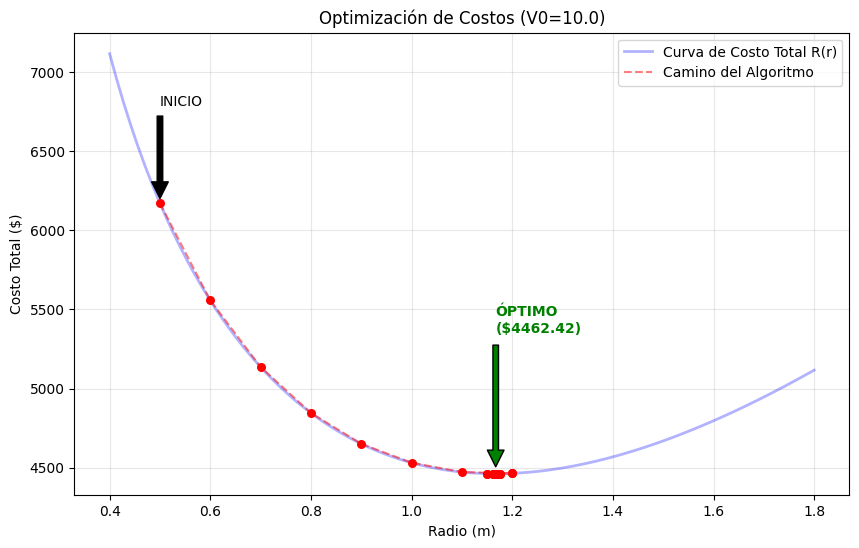

In [1]:
import math
import matplotlib.pyplot as plt

def optimizacion_con_grafico():
    print("=== OPTIMIZADOR DE TANQUE: REPORTE + GRÁFICO ===")

    # 1. Ingreso de Datos
    try:
        print("Por favor, ingrese los parámetros:")
        V0 = float(input("  > Volumen deseado (V0): "))
        C0 = float(input("  > Costo Base (C0): "))
        C1 = float(input("  > Factor C1: "))
        k = float(input("  > Constante k: "))
    except ValueError:
        print("Error: Ingrese solo números válidos.")
        return

    # --- Configuración Inicial ---
    r_actual = 0.5
    paso = 0.1

    # Listas para guardar la historia (para el gráfico)
    historia_r = []
    historia_costo = []

    # Función auxiliar de costo
    def calcular_R(r):
        if r <= 0: return float('inf')
        A = (2 * V0) / r + (2 * math.pi * r**2)
        c_A = C0 + C1 * math.exp(-k * A)
        return c_A * A

    costo_actual = calcular_R(r_actual)

    # Guardamos el punto inicial
    historia_r.append(r_actual)
    historia_costo.append(costo_actual)

    print(f"\n>> INICIO: Radio r={r_actual} | Costo=${costo_actual:.2f}")
    print("-" * 75)
    print(f"{'Iter':<5} | {'Acción':<18} | {'Radio (r)':<10} | {'Costo (R)':<12} | {'Cambio'}")
    print("-" * 75)

    # --- Bucle de Optimización ---
    for i in range(1, 21):
        r_derecha = r_actual + paso
        r_izquierda = r_actual - paso
        if r_izquierda <= 0.01: r_izquierda = 0.01

        costo_derecha = calcular_R(r_derecha)
        costo_izquierda = calcular_R(r_izquierda)

        # Lógica de movimiento
        if costo_derecha < costo_actual:
            accion = "Mover DERECHA ->"
            diferencia = costo_derecha - costo_actual
            r_actual = r_derecha
            costo_actual = costo_derecha

        elif costo_izquierda < costo_actual:
            accion = "<- Mover IZQUIERDA"
            diferencia = costo_izquierda - costo_actual
            r_actual = r_izquierda
            costo_actual = costo_izquierda

        else:
            accion = "** REFINAR (Zoom) **"
            paso = paso / 2
            diferencia = 0.0
            # Guardamos el estado aunque no nos movamos (para ver el refinamiento en la gráfica)
            historia_r.append(r_actual)
            historia_costo.append(costo_actual)
            print(f"{i:<5} | {accion:<18} | {r_actual:<10.4f} | ${costo_actual:<11.2f} | Paso: {paso:.4f}")
            continue

        # Guardar en historial
        historia_r.append(r_actual)
        historia_costo.append(costo_actual)

        print(f"{i:<5} | {accion:<18} | {r_actual:<10.4f} | ${costo_actual:<11.2f} | {diferencia:+.4f}")

    # --- CÁLCULOS FINALES ---
    r_optimo = r_actual
    h_optimo = V0 / (math.pi * r_optimo**2)
    A_optima = (2 * V0) / r_optimo + (2 * math.pi * r_optimo**2)
    costo_por_area = C0 + C1 * math.exp(-k * A_optima)
    costo_total = costo_por_area * A_optima

    # --- REPORTE EN TEXTO ---
    print("=" * 75)
    print(">>> RESULTADOS FINALES <<<")
    print(f"GEOMETRÍA: r = {r_optimo:.5f} m | h = {h_optimo:.5f} m | Área = {A_optima:.5f} m^2")
    print(f"COSTOS:    $/m^2 = {costo_por_area:.5f} | TOTAL = ${costo_total:.2f}")
    print("=" * 75)
    print("Generando gráfico explicativo...")

    # --- GENERACIÓN DEL GRÁFICO ---
    plt.figure(figsize=(10, 6))

    # 1. Crear la curva azul de fondo (El paisaje de costos)
    # Generamos puntos desde un poco menos del inicio hasta un poco más del óptimo
    r_min_plot = min(historia_r) * 0.8
    r_max_plot = max(historia_r) * 1.5
    if r_max_plot == r_min_plot: r_max_plot += 1 # Evitar error si no se mueve

    puntos_r = [r_min_plot + x * (r_max_plot - r_min_plot)/100 for x in range(101)]
    puntos_costo = [calcular_R(r) for r in puntos_r]

    plt.plot(puntos_r, puntos_costo, label='Curva de Costo Total R(r)', color='blue', alpha=0.3, linewidth=2)

    # 2. Dibujar el camino del algoritmo (Puntos rojos conectados)
    plt.plot(historia_r, historia_costo, color='red', linestyle='--', alpha=0.5, label='Camino del Algoritmo')
    plt.scatter(historia_r, historia_costo, color='red', s=30, zorder=5)

    # 3. Marcar Inicio y Fin
    plt.annotate('INICIO', xy=(historia_r[0], historia_costo[0]), xytext=(historia_r[0], historia_costo[0]*1.1),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.annotate(f'ÓPTIMO\n(${costo_total:.2f})', xy=(r_optimo, costo_total), xytext=(r_optimo, costo_total*1.2),
                 arrowprops=dict(facecolor='green', shrink=0.05), color='green', fontweight='bold')

    plt.title(f'Optimización de Costos (V0={V0})')
    plt.xlabel('Radio (m)')
    plt.ylabel('Costo Total ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Mostrar gráfico
    plt.show()

if __name__ == "__main__":
    optimizacion_con_grafico()